In [2]:
import sys, os
from pathlib import Path
from google.colab import drive

# Mount Google Drive to access your files
drive.mount('/content/drive')

# TODO: Enter the root path on your PC where you have saved the unzipped
# assignment folder. This path should now be relative to '/content/drive/'.
# For example: '/content/drive/My Drive/CSCD618-DSCD604/Assignments'
ROOT = '/content/drive/MyDrive/'
# TODO: Enter the assignment folder e.g. 'assignment1'
ASSIGNMENT_FOLDER = 'assignment1'

assert ROOT is not None, "[!] Enter the root path."
assert ASSIGNMENT_FOLDER is not None, "[!] Enter the assignment foldername."

assignment_path = Path(os.path.join(ROOT, ASSIGNMENT_FOLDER))
sys.path.append(assignment_path)

# This downloads the CIFAR-10 dataset to your folder if it doesn't already exist.
# Ensure the path below correctly points to the 'csdc618_dscd604/datasets/' directory
# within your assignment folder.
%cd "$assignment_path"/csdc618_dscd604/datasets/
!bash get_datasets.sh
%cd "$assignment_path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/assignment1/csdc618_dscd604/datasets
/content/drive/MyDrive/assignment1


# Image Features Exercise

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image.

In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

**All of your work for this exercise will be done in this notebook.**

In [3]:
import random
import numpy as np
from csdc618_dscd604.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [4]:
from csdc618_dscd604.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'csdc618_dscd604/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [5]:
from csdc618_dscd604.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train Softmax classifier on features
Using the `Softmax` code developed earlier in the assignment, train `Softmax` classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

In [6]:
from csdc618_dscd604.classifiers.linear_classifier import Softmax

learning_rates = [1e-7, 1e-6]
regularization_strengths = [5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        # Train the classifier
        loss_hist = softmax.train(X_train_feats, y_train, learning_rate=lr, reg=reg,
                                  num_iters=1500, verbose=False)

        # Predict on the training set
        y_train_pred = softmax.predict(X_train_feats)
        train_accuracy = np.mean(y_train == y_train_pred)

        # Predict on the validation set
        y_val_pred = softmax.predict(X_val_feats)
        val_accuracy = np.mean(y_val == y_val_pred)

        results[(lr, reg)] = (train_accuracy, val_accuracy)

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*******
################################################################################
#                             END OF YOUR CODE                                 #
################################################################################

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved: %f' % best_val)

/content/drive/MyDrive/assignment1/csdc618_dscd604/classifiers/softmax.py:103: RuntimeWarning: divide by zero encountered in log
  correct_logprobs = -np.log(probs[np.arange(num_train), y])      # (N,)
/content/drive/MyDrive/assignment1/csdc618_dscd604/classifiers/softmax.py:105: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/content/drive/MyDrive/assignment1/csdc618_dscd604/classifiers/softmax.py:105: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
/content/drive/MyDrive/assignment1/csdc618_dscd604/classifiers/softmax.py:131: RuntimeWarning: overflow encountered in multiply
  dW += 2.0 * reg * W


lr 1.000000e-07 reg 5.000000e+05 train accuracy: 0.413224 val accuracy: 0.407000
lr 1.000000e-07 reg 5.000000e+06 train accuracy: 0.343898 val accuracy: 0.347000
lr 1.000000e-06 reg 5.000000e+05 train accuracy: 0.339041 val accuracy: 0.366000
lr 1.000000e-06 reg 5.000000e+06 train accuracy: 0.100265 val accuracy: 0.087000
best validation accuracy achieved: 0.407000


In [7]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.394


In [8]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


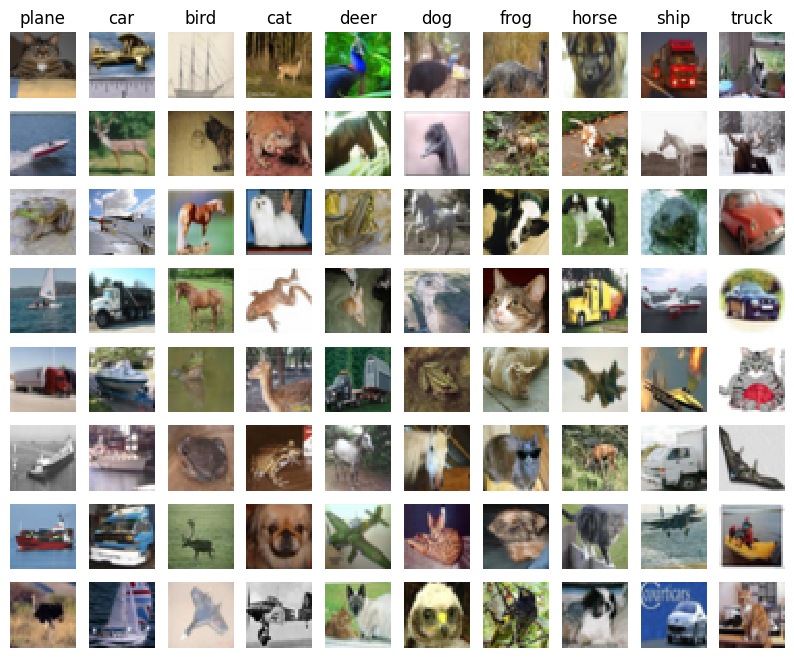

In [9]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    # Sample at most examples_per_class, or the total available if less than that
    num_examples = min(len(idxs), examples_per_class)
    if num_examples > 0:
        selected_idxs = np.random.choice(idxs, num_examples, replace=False)
        for i, idx in enumerate(selected_idxs):
            plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
            plt.imshow(X_test[idx].astype('uint8'))
            plt.axis('off')
            if i == 0:
                plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textbf {Your Answer:}}$ The misclassification results generally make sense, as errors often occur between visually similar classes or classes that share common features or backgrounds.

Here are some observations:

*   **Planes** are sometimes confused with **ships** or **birds**, likely due to similar backgrounds (sky, water) or general shapes in the image.
*   **Cars** and **trucks** are frequently misclassified as each other, which is expected given their structural similarities as vehicles.
*   **Animals** such as **cats**, **dogs**, **deer**, and **horses** are often confused with one another. This is common because they share many visual characteristics like fur, eyes, and overall body shapes. For example, a dog might be classified as a cat, or a deer as a horse.
*   **Frogs** can be misclassified, possibly with other small animals or even green objects in a natural setting.
*   **Ships** are sometimes confused with **planes** or **trucks**, which could be due to similar contexts (e.g., large objects on a background, or in the case of trucks, similar bulky forms).

Overall, the misclassifications highlight the limitations of the features in distinguishing fine-grained differences between visually analogous categories. The model struggles when classes have overlapping feature distributions, which is a common challenge in image classification.


---


## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels.

In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features.\
This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [10]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 170)
(49000, 169)


In [11]:
from csdc618_dscd604.classifiers.fc_net import TwoLayerNet
from csdc618_dscd604.solver import Solver

input_dim = X_train_feats.shape[1]
num_classes = 10

data = {
    'X_train': X_train_feats,
    'y_train': y_train,
    'X_val': X_val_feats,
    'y_val': y_val,
    'X_test': X_test_feats,
    'y_test': y_test,
}

best_net = None

################################################################################
# TODO: Train a two-layer neural network on image features.                    #
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

best_val_acc = -1
results = {}

def run(hd, ws, lr, reg, rule, epochs):
    """Train one config and return (val_acc, model). Diverged runs are caught."""
    global best_val_acc, best_net
    model = TwoLayerNet(input_dim, hd, num_classes, weight_scale=ws, reg=reg)
    solver = Solver(
        model, data,
        update_rule=rule,
        optim_config={'learning_rate': lr},
        lr_decay=0.95,
        num_epochs=epochs,
        batch_size=200,
        verbose=False, print_every=100000,
    )
    solver.train()
    val_acc = solver.best_val_acc          # Solver already restores best params
    results[(hd, ws, lr, reg, rule)] = val_acc
    print('%-5s hd=%4d ws=%.0e lr=%.0e reg=%.0e -> val=%.4f'
          % (rule, hd, ws, lr, reg, val_acc))
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_net = model
    return val_acc

# ---- Stage 1: coarse Adam search (shorter, to locate the good region) ----
print('=== Stage 1: coarse Adam search ===')
for hd in [500, 800]:
    for lr in [5e-4, 1e-3, 2e-3]:
        for reg in [1e-4, 5e-4, 1e-3]:
            run(hd, ws=1e-2, lr=lr, reg=reg, rule='adam', epochs=15)

# ---- Stage 2: refine around the Stage 1 winner with longer training ----
print('\n=== Stage 2: refined search (longer training) ===')
best_hd, best_ws, best_lr, best_reg, _ = max(results, key=results.get)

# Search a tight neighborhood around the best learning rate / reg, train longer.
lr_candidates  = sorted({best_lr * 0.5, best_lr, best_lr * 2})
reg_candidates = sorted({max(best_reg * 0.5, 1e-5), best_reg, best_reg * 2})

for lr in lr_candidates:
    for reg in reg_candidates:
        run(best_hd, best_ws, lr, reg, rule='adam', epochs=30)

# ---- Results ----
print('\nBest validation accuracy: %.4f' % best_val_acc)
print('Best hyperparameters (hd, ws, lr, reg, rule):',
      max(results, key=results.get))

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*******
################################################################################
#                             END OF YOUR CODE                                 #
################################################################################

# Evaluate the chosen model ONCE on the held-out test set.
test_acc = (best_net.loss(data['X_test']).argmax(axis=1) == data['y_test']).mean()
print('Test accuracy: %.4f' % test_acc)

=== Stage 1: coarse Adam search ===
adam  hd= 500 ws=1e-02 lr=5e-04 reg=1e-04 -> val=0.6180
adam  hd= 500 ws=1e-02 lr=5e-04 reg=5e-04 -> val=0.6150
adam  hd= 500 ws=1e-02 lr=5e-04 reg=1e-03 -> val=0.6340
adam  hd= 500 ws=1e-02 lr=1e-03 reg=1e-04 -> val=0.6220
adam  hd= 500 ws=1e-02 lr=1e-03 reg=5e-04 -> val=0.6180
adam  hd= 500 ws=1e-02 lr=1e-03 reg=1e-03 -> val=0.6270
adam  hd= 500 ws=1e-02 lr=2e-03 reg=1e-04 -> val=0.6060
adam  hd= 500 ws=1e-02 lr=2e-03 reg=5e-04 -> val=0.6080
adam  hd= 500 ws=1e-02 lr=2e-03 reg=1e-03 -> val=0.6050
adam  hd= 800 ws=1e-02 lr=5e-04 reg=1e-04 -> val=0.6210
adam  hd= 800 ws=1e-02 lr=5e-04 reg=5e-04 -> val=0.6180
adam  hd= 800 ws=1e-02 lr=5e-04 reg=1e-03 -> val=0.6280
adam  hd= 800 ws=1e-02 lr=1e-03 reg=1e-04 -> val=0.6250
adam  hd= 800 ws=1e-02 lr=1e-03 reg=5e-04 -> val=0.6210
adam  hd= 800 ws=1e-02 lr=1e-03 reg=1e-03 -> val=0.6160
adam  hd= 800 ws=1e-02 lr=2e-03 reg=1e-04 -> val=0.5930
adam  hd= 800 ws=1e-02 lr=2e-03 reg=5e-04 -> val=0.6120
adam  hd= 80

In [12]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.603


In [13]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
